In [1]:
from HGEMMD_ import HGEMMD, load_feature_and_hyperedge, HGNN_conv
import os, re
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
data_dir = './data/data_MOGONET/BRCA'; hidden_dim = [500]; num_epoch = 2500; lr = 1e-4; step_size = 500; num_class = 5; lambda_1 = 1; lambda_2 = 1; k = 300
np.random.seed(24)
torch.manual_seed(24)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

data_list, label, data_train_indices, data_test_indices, hyperedge_multi_omics, pre_calc_G = load_feature_and_hyperedge(data_dir, use_mRNA=True, use_meth=True, use_miRNA=True, k_list=[k], is_prob=True, m_prob=1, edge_type='euclid')
dim_list = [data.shape[1] for data in data_list]
data_list = [torch.FloatTensor(data).to(device) for data in data_list]
label = torch.LongTensor(label).to(device)
pre_calc_G = torch.FloatTensor(pre_calc_G).to(device)

model = HGEMMD(dim_list, hidden_dim, num_class, dropout=0.5).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=0.2)
# for epoch in range(1, num_epoch + 1):
#     model.train()
#     optimizer.zero_grad()
#     loss = model.forward_criterion(data_list=data_list, labeled_indices=data_train_indices, unlabeled_indices=data_test_indices, label=label, pre_calc_G=pre_calc_G, lambda_1=lambda_1, lambda_2=lambda_2)
#     loss.backward()
#     optimizer.step()
#     scheduler.step()
#     if epoch % 50 == 0:
#         print('Training Epoch {:d}: Loss={:.5f}'.format(epoch, loss.cpu().detach().numpy()))
#         model.eval()
#         with torch.no_grad():
#             logit, _, _, _, _, _, _ = model.forward(data_list, pre_calc_G)
#             prob = F.softmax(logit, dim=1).data.cpu().numpy()
#             label_test = label[data_train_indices]
#             prob_test = prob[data_train_indices]
#         acc = accuracy_score(label_test.cpu().numpy(), prob_test.argmax(1))
#         f1_weighted = f1_score(label_test.cpu().numpy(), prob_test.argmax(1), average='weighted')
#         f1_macro = f1_score(label_test.cpu().numpy(), prob_test.argmax(1), average='macro')
#         print('Training Epoch {:d}: Train ACC={:.5f}, F1_weighted={:.5f}, F1_macro={:.5f}'.format(epoch, acc, f1_weighted, f1_macro))
#         with torch.no_grad():
#             logit, _, _, _, _, _, _ = model.forward(data_list, pre_calc_G)
#             prob = F.softmax(logit, dim=1).data.cpu().numpy()
#             label_test = label[data_test_indices]
#             prob_test = prob[data_test_indices]
#         acc = accuracy_score(label_test.cpu().numpy(), prob_test.argmax(1))
#         f1_weighted = f1_score(label_test.cpu().numpy(), prob_test.argmax(1), average='weighted')
#         f1_macro = f1_score(label_test.cpu().numpy(), prob_test.argmax(1), average='macro')
#         print('Training Epoch {:d}: Test ACC={:.5f}, F1_weighted={:.5f}, F1_macro={:.5f}'.format(epoch, acc, f1_weighted, f1_macro))
#     torch.save(model.state_dict(), os.path.join('./result/data_MOGONET', "checkpoint_BRCA.pt"))
best_checkpoint = torch.load(os.path.join('./result/data_MOGONET', 'checkpoint_BRCA.pt'))
# model.load_state_dict(best_checkpoint)
# Filter out keys that don't exist in the current model (e.g., 'HGNN.G' from older version)
model_dict = model.state_dict()
filtered_checkpoint = {k: v for k, v in best_checkpoint.items() if k in model_dict}
print(f"Loaded {len(filtered_checkpoint)}/{len(model_dict)} parameters from checkpoint")
if len(filtered_checkpoint) < len(model_dict):
    missing = set(model_dict.keys()) - set(filtered_checkpoint.keys())
    print(f"Missing keys (will use random init): {missing}")
model.load_state_dict(filtered_checkpoint, strict=False)
model.eval()
with torch.no_grad():
    MMlogit, FeatureInfo, TCPLogit, TCPConfidence, ModalityEmbedding, MMfeature, MMfeature_hypergraph = model.forward(data_list, pre_calc_G)

data_list mRNA shape: (875, 1000)
data_list meth shape: (875, 1000)
data_list miRNA shape: (875, 503)
label shape: (875,)
data_train_indices shape: (612,)
data_test_indices shape: (263,)
hyperedge_multi_omics shape: (875, 2625)
pre_calculate hypegraph G shape: (875, 875)
label shape: (875,)
Loaded 28/28 parameters from checkpoint


# Visualization of Feature Informativeness and Modality Informativeness

In [4]:
FeatureInfo = [FeatureInfo[0].cpu().numpy(), FeatureInfo[1].cpu().numpy(), FeatureInfo[2].cpu().numpy()]
print(FeatureInfo[0].shape, FeatureInfo[1].shape, FeatureInfo[2].shape)
feature_name_0 = pd.read_csv(os.path.join(data_dir, "1_featname.csv"), header=None).values.flatten().tolist()
feature_name_0 = [re.sub(r'\|.*$', '', input_string) for input_string in feature_name_0]
feature_name_1 = pd.read_csv(os.path.join(data_dir, "2_featname.csv"), header=None).values.flatten().tolist()
feature_name_2 = pd.read_csv(os.path.join(data_dir, "3_featname.csv"), header=None).values.flatten().tolist()
print(len(feature_name_0), len(feature_name_1), len(feature_name_2))
modality_dict = {0: 'mRNA expression', 1: 'DNA methylation', 2: 'miRNA expression'}
TCPConfidence = [TCPConfidence[0].cpu().numpy(), TCPConfidence[1].cpu().numpy(), TCPConfidence[2].cpu().numpy()]
print(TCPConfidence[0].shape, TCPConfidence[1].shape, TCPConfidence[2].shape)
TCPConfidence = np.concatenate(TCPConfidence, axis=1)
print(TCPConfidence.shape)
data_list = [data_list[0].cpu().numpy(), data_list[1].cpu().numpy(), data_list[2].cpu().numpy()]
label = label.cpu().numpy()

(875, 1000) (875, 1000) (875, 503)
1000 1000 503
(875, 1) (875, 1) (875, 1)
(875, 3)


In [7]:
# data = FeatureInfo[0][:50, 30:60]
# plt.figure(figsize=(6, 8))
# sns.heatmap(data, annot=False, cmap='YlGnBu', cbar=False, xticklabels=True, yticklabels=True, linewidths=0.7, linecolor='white', vmin=0, vmax=1, cbar_kws={'ticks': [0, 0.2, 0.4, 0.6, 0.8, 1]})
# plt.xticks(ticks=np.arange(0.5, data.shape[1], 1), labels=feature_name_0[30:60], rotation=90, ha='center')
# plt.yticks(ticks=np.arange(0.5, data.shape[0], 2), labels='')
# plt.show()
# data = FeatureInfo[1][:50, 60:90]
# plt.figure(figsize=(6, 8))
# sns.heatmap(data, annot=False, cmap='YlGnBu', cbar=False, xticklabels=True, yticklabels=True, linewidths=0.7, linecolor='white', vmin=0, vmax=1, cbar_kws={'ticks': [0, 0.2, 0.4, 0.6, 0.8, 1]})
# plt.xticks(ticks=np.arange(0.5, data.shape[1], 1), labels=feature_name_1[60:90], rotation=90, ha='center')
# plt.yticks(ticks=np.arange(0.5, data.shape[0], 2), labels='')
# plt.show()
# data = FeatureInfo[2][:50, 90:120]
# plt.figure(figsize=(6, 8))
# sns.heatmap(data, annot=False, cmap='YlGnBu', cbar=False, xticklabels=True, yticklabels=True, linewidths=0.7, linecolor='white', vmin=0, vmax=1, cbar_kws={'ticks': [0, 0.2, 0.4, 0.6, 0.8, 1]})
# plt.xticks(ticks=np.arange(0.5, data.shape[1], 1), labels=feature_name_2[90:120], rotation=90, ha='center')
# plt.yticks(ticks=np.arange(0.5, data.shape[0], 2), labels='')
# plt.show()
# data = TCPConfidence[:50, :]
# plt.figure(figsize=(0.75, 8))
# sns.heatmap(data, annot=False, cmap='YlGnBu', cbar=False, xticklabels=True, yticklabels=True, linewidths=0.7, linecolor='white', vmin=0, vmax=1, cbar_kws={'ticks': [0, 0.2, 0.4, 0.6, 0.8, 1]})
# plt.xticks(ticks=np.arange(0.5, data.shape[1], 1), labels=modality_dict.values(), rotation=90, ha='center')
# plt.yticks(ticks=np.arange(0.5, data.shape[0], 2), labels='')
# plt.show()

# Modality Dynamics Analysis

In [5]:
TCPLogit = [F.softmax(TCPLogit[0], dim=1).data.cpu().numpy(), F.softmax(TCPLogit[1], dim=1).data.cpu().numpy(), F.softmax(TCPLogit[2], dim=1).data.cpu().numpy()]
TCPConfidence = [TCPConfidence[:, 0], TCPConfidence[:, 1], TCPConfidence[:, 2]] # shape: 3 * n_sample
acc_list = []
tcp_list = []
for i in range(len(TCPLogit)):
    pred = TCPLogit[i].argmax(1)
    acc_list.append(np.round(accuracy_score(label, pred), 2))
for i in range(len(TCPConfidence)):
    tcp_mean = TCPConfidence[i].mean()
    tcp_list.append(np.round(tcp_mean, 2))
print('Test ACC:', acc_list)
print('Test TCP:', tcp_list)

Test ACC: [0.87, 0.79, 0.81]
Test TCP: [0.81, 0.66, 0.71]


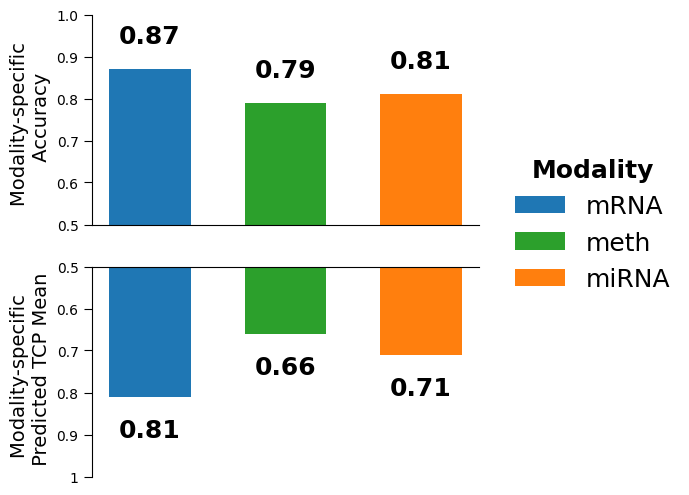

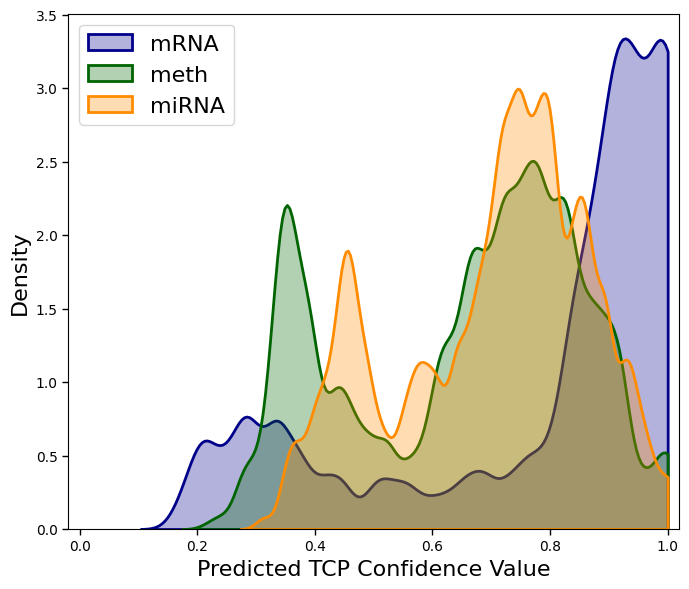

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6), sharex=True)
categories = ['mRNA', 'meth', 'miRNA']  # A类数据
colors = {'mRNA': '#1f77b4', 'meth': '#2ca02c', 'miRNA': '#ff7f0e'}  # 相同颜色用于A和B
# Plot the first bar chart (representing A)
for category, value in zip(categories, acc_list):
    ax1.bar(category, value, color=colors[category], width=0.6, label=category)
    # ax1.text(category, value + 0.05, str(value), ha='center', va='bottom', fontsize=18, fontweight='bold', style='italic')
    ax1.text(category, value + 0.05, str(value), ha='center', va='bottom', fontsize=18, fontweight='bold')
ax1.set_xticklabels('') # Hide the x-axis ticks and labels for the first plot
ax1.tick_params(axis='x', direction='out', length=6, bottom=False, top=False)
ax1.tick_params(axis='y', direction='out', length=6, left=True, right=False)
ax1.set_ylim(0.5, 1)
# ax1.set_ylabel('Modality-specific \n Accuracy', fontsize=14, fontweight='normal', style='italic')
ax1.set_ylabel('Modality-specific \n Accuracy', fontsize=14, fontweight='normal')
ax1.axhline(0, color='black', linewidth=3.5) 
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
# ax1.legend(title='Modality', loc='center right', frameon=False, bbox_to_anchor=(1.55, 0), prop={'size': 18, 'weight': 'normal', 'style': 'italic'}, title_fontproperties={'size': 18, 'weight': 'bold', 'style': 'italic'})
ax1.legend(title='Modality', loc='center right', frameon=False, bbox_to_anchor=(1.55, 0), prop={'size': 18, 'weight': 'normal'}, title_fontproperties={'size': 18, 'weight': 'bold'})
# Plot the second bar chart (representing B)
for category, value in zip(categories, tcp_list):
    ax2.bar(category, -value, color=colors[category], width=0.6)
    # ax2.text(category, -value - 0.05, str(value), ha='center', va='top', fontsize=18, fontweight='bold', style='italic')
    ax2.text(category, -value - 0.05, str(value), ha='center', va='top', fontsize=18, fontweight='bold')
ax2.set_ylim(-1, -0.5)
ax2.set_yticks([-1, -0.9, -0.8, -0.7, -0.6, -0.5])
ax2.set_yticklabels([1, 0.9, 0.8, 0.7, 0.6, 0.5])
# ax2.set_ylabel('Modality-specific \n Predicted TCP Mean', fontsize=14, fontweight='normal', style='italic') # $\widehat{TCP}$
ax2.set_ylabel('Modality-specific \n Predicted TCP Mean', fontsize=14, fontweight='normal') # $\widehat{TCP}$
ax2.axhline(0, color='black', linewidth=1.5)
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.set_xticks(range(len(categories)))
# ax2.set_xticklabels('', fontsize=10, fontweight='bold', style='italic') # Hide the x-axis ticks and labels for the second plot
ax2.set_xticklabels('', fontsize=10, fontweight='bold') # Hide the x-axis ticks and labels for the second plot
ax2.tick_params(axis='x', direction='out', length=6, bottom=False, top=False)
ax2.tick_params(axis='y', direction='out', length=6, left=True, right=False)
# plt.tight_layout()
plt.savefig(f'./figure/data_MOGONET/intra_5.png', dpi=400, bbox_inches='tight')
plt.show()

# Plotting the KDE for each column (mRNA, meth, miRNA)
# sns.set_theme(style="darkgrid")
plt.figure(figsize=(7, 6))
df = pd.DataFrame(np.array(TCPConfidence).T, columns=['mRNA', 'meth', 'miRNA']).astype(np.float64)
sns.kdeplot(df['mRNA'], label='mRNA', fill=True, clip=(0, 1), bw_adjust=0.3, color='darkblue', alpha=0.3, linewidth=2)
sns.kdeplot(df['meth'], label='meth', fill=True, clip=(0, 1), bw_adjust=0.3, color='darkgreen', alpha=0.3, linewidth=2)
sns.kdeplot(df['miRNA'], label='miRNA', fill=True, clip=(0, 1), bw_adjust=0.3, color='darkorange', alpha=0.3, linewidth=2)
plt.tick_params(axis='both', labelsize=10, labelcolor='black', direction='out', length=4, width=1)
plt.xlim(-0.02, 1.02)
# font_dict = {'family': 'sans-serif', 'weight': 'normal', 'size': 16, 'style': 'italic'}
font_dict = {'family': 'sans-serif', 'weight': 'normal', 'size': 16}
plt.xticks(fontsize=10, fontstyle='normal', fontweight='normal', fontname='sans-serif')
plt.yticks(fontsize=10, fontstyle='normal', fontweight='normal', fontname='sans-serif')
plt.xlabel('Predicted TCP Confidence Value', fontdict=font_dict)
plt.ylabel('Density', fontdict=font_dict)
plt.legend(loc='upper left', prop=font_dict)
# plt.title('KDE Plot for mRNA, meth, and miRNA', fontdict=font_dict)
plt.grid(False)
plt.tight_layout()
plt.savefig(f'./figure/data_MOGONET/intra_4.png', dpi=400, bbox_inches='tight')
plt.show()


# Feature Informativeness Analysis

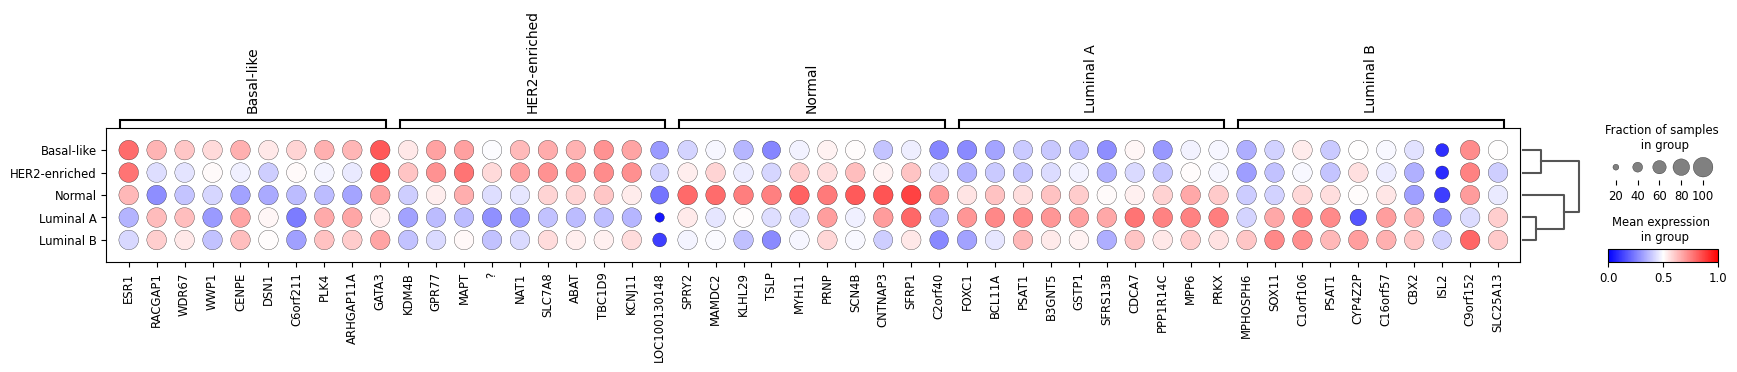

444
0.444


In [9]:
mRNA_feature_info_sum = np.sum(FeatureInfo[0], axis=0)
mRNA_feature_info_sum_top_10 = np.argsort(mRNA_feature_info_sum)[::-1][:10]
mRNA_feature_info_sum_top_20 = np.argsort(mRNA_feature_info_sum)[::-1][:20]
mRNA_feature_info_sum_top_30 = np.argsort(mRNA_feature_info_sum)[::-1][:30]
mRNA_feature_info_sum_top_40 = np.argsort(mRNA_feature_info_sum)[::-1][:40]
mRNA_feature_info_sum_top_50 = np.argsort(mRNA_feature_info_sum)[::-1][:50]
mRNA_feature_info_sum_top_60 = np.argsort(mRNA_feature_info_sum)[::-1][:60]
mRNA_feature_info_sum_top_70 = np.argsort(mRNA_feature_info_sum)[::-1][:70]
mRNA_feature_info_sum_top_80 = np.argsort(mRNA_feature_info_sum)[::-1][:80]
mRNA_feature_info_sum_top_90 = np.argsort(mRNA_feature_info_sum)[::-1][:90]
mRNA_feature_info_sum_top_100 = np.argsort(mRNA_feature_info_sum)[::-1][:100]
mRNA_feature_info_sum_top_10_name = [feature_name_0[i] for i in mRNA_feature_info_sum_top_10]
mRNA_feature_info_sum_top_20_name = [feature_name_0[i] for i in mRNA_feature_info_sum_top_20]
mRNA_feature_info_sum_top_30_name = [feature_name_0[i] for i in mRNA_feature_info_sum_top_30]
mRNA_feature_info_sum_top_40_name = [feature_name_0[i] for i in mRNA_feature_info_sum_top_40]
mRNA_feature_info_sum_top_50_name = [feature_name_0[i] for i in mRNA_feature_info_sum_top_50]
mRNA_feature_info_sum_top_60_name = [feature_name_0[i] for i in mRNA_feature_info_sum_top_60]
mRNA_feature_info_sum_top_70_name = [feature_name_0[i] for i in mRNA_feature_info_sum_top_70]
mRNA_feature_info_sum_top_80_name = [feature_name_0[i] for i in mRNA_feature_info_sum_top_80]
mRNA_feature_info_sum_top_90_name = [feature_name_0[i] for i in mRNA_feature_info_sum_top_90]
mRNA_feature_info_sum_top_100_name = [feature_name_0[i] for i in mRNA_feature_info_sum_top_100]
mRNA_feature_info_sum_top_10_value = mRNA_feature_info_sum[mRNA_feature_info_sum_top_10]
mRNA_feature_info_sum_top_20_value = mRNA_feature_info_sum[mRNA_feature_info_sum_top_20]
mRNA_feature_info_sum_top_30_value = mRNA_feature_info_sum[mRNA_feature_info_sum_top_30]
mRNA_feature_info_sum_top_40_value = mRNA_feature_info_sum[mRNA_feature_info_sum_top_40]
mRNA_feature_info_sum_top_50_value = mRNA_feature_info_sum[mRNA_feature_info_sum_top_50]
mRNA_feature_info_sum_top_60_value = mRNA_feature_info_sum[mRNA_feature_info_sum_top_60]
mRNA_feature_info_sum_top_70_value = mRNA_feature_info_sum[mRNA_feature_info_sum_top_70]
mRNA_feature_info_sum_top_80_value = mRNA_feature_info_sum[mRNA_feature_info_sum_top_80]
mRNA_feature_info_sum_top_90_value = mRNA_feature_info_sum[mRNA_feature_info_sum_top_90]
mRNA_feature_info_sum_top_100_value = mRNA_feature_info_sum[mRNA_feature_info_sum_top_100]

import scanpy as sc
import pandas as pd
label_dict = {0: 'Normal', 1: 'Luminal A', 2: 'Luminal B', 3: 'HER2-enriched', 4: 'Basal-like'}
label_name = [label_dict[i] for i in label]
adata = sc.AnnData(X=data_list[0], obs=pd.DataFrame(label_name, columns=['label']), var=pd.DataFrame(index=feature_name_0, columns=['feature_name']))
adata.obs['label'] = adata.obs['label'].astype('category')
# Perform differential expression analysis (for example, between Normal and other groups)
sc.tl.rank_genes_groups(adata, 'label', method='t-test', use_rep='X')  # You can change the method here
sc.tl.filter_rank_genes_groups(adata, min_fold_change=1.5)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=10, use_raw=False, color_map='bwr', show=True, vmin=0, vmax=1, colorbar_title='Mean expression \n in group', size_title='Fraction of samples \n in group', title='')

top_genes = []
top_20_genes_normal = adata.uns['rank_genes_groups']['names']['Normal'][:20]  # Get top 20 genes for Normal group
top_20_genes_luminal_a = adata.uns['rank_genes_groups']['names']['Luminal A'][:20]  # Get top 20 genes for Luminal A group
top_20_genes_luminal_b = adata.uns['rank_genes_groups']['names']['Luminal B'][:20]  # Get top 20 genes for Luminal B group
top_20_genes_her2 = adata.uns['rank_genes_groups']['names']['HER2-enriched'][:20]  # Get top 20 genes for HER2-enriched group
top_20_genes_basal = adata.uns['rank_genes_groups']['names']['Basal-like'][:20]  # Get top 20 genes for Basal-like group
for group in adata.obs['label'].cat.categories:
    ranked_genes = adata.uns['rank_genes_groups']['names'][group]
    top_genes_group = ranked_genes[:100]  # Get top 100 genes for each group, sort by scores.
    # print(adata.uns['rank_genes_groups']['logfoldchanges'][group])
    # print(adata.uns['rank_genes_groups']['scores'][group])
    top_genes.extend(top_genes_group)
unique_top_genes = list(set(top_genes))
print(len(unique_top_genes))
print(len(unique_top_genes)/len(feature_name_0))

In [18]:
# from gprofiler import gprofiler
# ranked_genes_basal_like = adata.uns['rank_genes_groups']['names']['Basal-like']
# ranked_genes_basal_like = ranked_genes_basal_like[:10]
# ranked_genes_basal_like = ranked_genes_basal_like.tolist()
# print(f"Top 10 genes for Basal-like:", ranked_genes_basal_like)
# gp = gprofiler.GProfiler(return_dataframe=True)
# enrichment_results_basal_like = gp.profile(organism='hsapiens', query=ranked_genes_basal_like, sources=['GO:BP'])
# print(f"Enrichment results for Basal-like:")
# print(enrichment_results_basal_like[['source', 'name', 'query_size', 'term_size', 'intersection_size', 'p_value']])
# # add a column log_p_value to the enrichment_results_basal_like DataFrame
# enrichment_results_basal_like['log_p_value'] = -np.log10(enrichment_results_basal_like['p_value'])
# # add a column richfactor to the enrichment_results_basal_like DataFrame
# enrichment_results_basal_like['richfactor'] = enrichment_results_basal_like['intersection_size'] / enrichment_results_basal_like['term_size']

# plt.figure(figsize=(6, 4))
# sns.barplot(x='log_p_value', y='name', data=enrichment_results_basal_like, palette='Purples_r', hue='name')
# plt.xlabel('-log10(p - value)', fontdict={'size': 12, 'weight': 'normal', 'style': 'italic'})
# plt.ylabel('')
# plt.tick_params(axis='y', which='both', left=False)
# plt.yticks(fontsize=10, fontstyle='italic', fontweight='normal')
# plt.yticks(rotation=15, ha='right')
# sns.despine(left=True, right=True, top=True)
# plt.tight_layout()
# plt.show()

# fig, ax = plt.subplots(figsize=(6, 6))
# # fig.patch.set_facecolor('lightgray')
# scatter = sns.scatterplot(data=enrichment_results_basal_like, x='richfactor', y='name', size='intersection_size', hue='log_p_value', palette='viridis', sizes=(50, 300), edgecolor='black', linewidth=0.8, ax=ax)
# plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='black')
# # plt.gca().patch.set_facecolor('lightgray')
# plt.gca().spines['top'].set_visible(True)
# plt.gca().spines['right'].set_visible(True)
# plt.xticks(fontsize=18, fontstyle='italic')
# plt.yticks(fontsize=18, fontstyle='italic')
# plt.xlabel('RichFactor', fontdict={'weight': 'normal', 'size': 18, 'style': 'italic'})
# plt.ylabel('', fontdict={'weight': 'normal', 'size': 18, 'style': 'italic'})
# for spine in ['top', 'right', 'left', 'bottom']:
#     scatter.spines[spine].set_color('black')
#     scatter.spines[spine].set_linewidth(1.5)
# # cbar = plt.colorbar(scatter.collections[0], ax=scatter)
# # cbar.set_label('-Log10_Pvalue')
# handles, labels = scatter.get_legend_handles_labels()
# plt.legend(handles=handles[0:], labels=labels[0:], title="", loc='center left', bbox_to_anchor=(2.50, 0.5),
#            borderpad=0, labelspacing=0.2, handlelength=1, handletextpad=1.5, frameon=False, framealpha=0, 
#            fancybox=False, alignment='center', prop={'weight': 'normal', 'size': 18, 'style': 'italic'})
# ax.yaxis.tick_right()
# plt.yticks(fontsize=18, fontstyle='italic')
# # plt.gca().invert_yaxis()
# # plt.tight_layout()
# plt.show()

8 0.8 True
17 0.85 True
22 0.7333333333333333 True
28 0.7 True
36 0.72 True
42 0.7 True
49 0.7 True
53 0.6625 True
58 0.6444444444444445 True
65 0.65 True


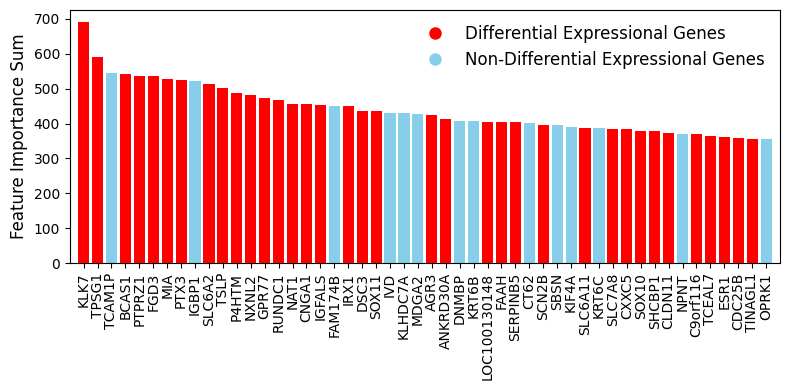

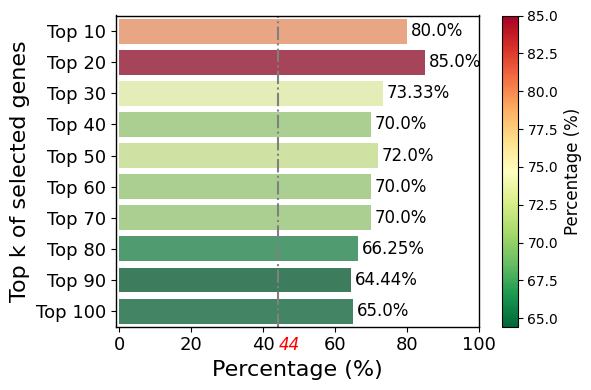

In [27]:
overlap_genes_top_10 = list(set(mRNA_feature_info_sum_top_10_name) & set(unique_top_genes)); print(len(overlap_genes_top_10), len(overlap_genes_top_10)/10, len(overlap_genes_top_10)/10 > len(unique_top_genes)/len(feature_name_0))
overlap_genes_top_20 = list(set(mRNA_feature_info_sum_top_20_name) & set(unique_top_genes)); print(len(overlap_genes_top_20), len(overlap_genes_top_20)/20, len(overlap_genes_top_20)/20 > len(unique_top_genes)/len(feature_name_0))
overlap_genes_top_30 = list(set(mRNA_feature_info_sum_top_30_name) & set(unique_top_genes)); print(len(overlap_genes_top_30), len(overlap_genes_top_30)/30, len(overlap_genes_top_30)/30 > len(unique_top_genes)/len(feature_name_0))
overlap_genes_top_40 = list(set(mRNA_feature_info_sum_top_40_name) & set(unique_top_genes)); print(len(overlap_genes_top_40), len(overlap_genes_top_40)/40, len(overlap_genes_top_40)/40 > len(unique_top_genes)/len(feature_name_0))
overlap_genes_top_50 = list(set(mRNA_feature_info_sum_top_50_name) & set(unique_top_genes)); print(len(overlap_genes_top_50), len(overlap_genes_top_50)/50, len(overlap_genes_top_50)/50 > len(unique_top_genes)/len(feature_name_0))
overlap_genes_top_60 = list(set(mRNA_feature_info_sum_top_60_name) & set(unique_top_genes)); print(len(overlap_genes_top_60), len(overlap_genes_top_60)/60, len(overlap_genes_top_60)/60 > len(unique_top_genes)/len(feature_name_0))
overlap_genes_top_70 = list(set(mRNA_feature_info_sum_top_70_name) & set(unique_top_genes)); print(len(overlap_genes_top_70), len(overlap_genes_top_70)/70, len(overlap_genes_top_70)/70 > len(unique_top_genes)/len(feature_name_0))
overlap_genes_top_80 = list(set(mRNA_feature_info_sum_top_80_name) & set(unique_top_genes)); print(len(overlap_genes_top_80), len(overlap_genes_top_80)/80, len(overlap_genes_top_80)/80 > len(unique_top_genes)/len(feature_name_0))
overlap_genes_top_90 = list(set(mRNA_feature_info_sum_top_90_name) & set(unique_top_genes)); print(len(overlap_genes_top_90), len(overlap_genes_top_90)/90, len(overlap_genes_top_90)/90 > len(unique_top_genes)/len(feature_name_0))
overlap_genes_top_100 = list(set(mRNA_feature_info_sum_top_100_name) & set(unique_top_genes)); print(len(overlap_genes_top_100), len(overlap_genes_top_100)/100, len(overlap_genes_top_100)/100 > len(unique_top_genes)/len(feature_name_0))

colors = ['red' if gene in overlap_genes_top_100 else 'skyblue' for gene in mRNA_feature_info_sum_top_100_name]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(50), mRNA_feature_info_sum_top_50_value, align='center', color=colors)
ax.set_xticks(range(50))
# ax.set_xticklabels(mRNA_feature_info_sum_top_50_name, fontsize=8, rotation=90, fontstyle='italic')
ax.set_xticklabels(mRNA_feature_info_sum_top_50_name, fontsize=10, rotation=90)
ax.set_xlim(-1, 50)
# ax.set_ylabel('Feature Importance Sum', fontsize=12, fontstyle='italic')
ax.set_ylabel('Feature Importance Sum', fontsize=12)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Differential Expressional Genes'),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=10, label='Non-Differential Expressional Genes')]
# ax.legend(handles=handles, loc='upper right', fontsize=10, frameon=False, prop={'size': 12, 'weight': 'normal', 'style': 'italic'}, title_fontproperties={'size': 10, 'weight': 'bold', 'style': 'italic'})
ax.legend(handles=handles, loc='upper right', fontsize=10, frameon=False, prop={'size': 12, 'weight': 'normal'}, title_fontproperties={'size': 10, 'weight': 'bold'})
plt.grid(False)
plt.tight_layout()
plt.savefig(f'./figure/data_MOGONET/intra_2.png', dpi=400, bbox_inches='tight')
plt.show()

overlap_genes_list = [overlap_genes_top_10, overlap_genes_top_20, overlap_genes_top_30, overlap_genes_top_40, overlap_genes_top_50, overlap_genes_top_60, overlap_genes_top_70, overlap_genes_top_80, overlap_genes_top_90, overlap_genes_top_100]
overlap_genes_num_list = [len(overlap_genes_top_10)/10, len(overlap_genes_top_20)/20, len(overlap_genes_top_30)/30, len(overlap_genes_top_40)/40, len(overlap_genes_top_50)/50, len(overlap_genes_top_60)/60, len(overlap_genes_top_70)/70, len(overlap_genes_top_80)/80, len(overlap_genes_top_90)/90, len(overlap_genes_top_100)/100]
df = pd.DataFrame(overlap_genes_num_list, columns=['Overlap Genes'], index=['Top 10', 'Top 20', 'Top 30', 'Top 40', 'Top 50', 'Top 60', 'Top 70', 'Top 80', 'Top 90', 'Top 100'])
df['Overlap Genes'] = df['Overlap Genes'] * 100
norm = plt.Normalize(df['Overlap Genes'].min(), df['Overlap Genes'].max())
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
plt.figure(figsize=(6, 4))
ax = sns.barplot(x='Overlap Genes', y=df.index, data=df, palette="RdYlGn_r", hue='Overlap Genes', dodge=False, orient='h', alpha=0.8)
for i, v in enumerate(df['Overlap Genes']):
    # ax.text(v + 1, i, str(round(v, 2)) + '%', color='black', va='center', fontsize=12, fontweight='normal', style='italic')
    ax.text(v + 1, i, str(round(v, 2)) + '%', color='black', va='center', fontsize=12, fontweight='normal')
ax.text(len(unique_top_genes)/len(feature_name_0)*100 + 0.01, len(df)+0.1, '{}'.format(int(round(len(unique_top_genes)/len(feature_name_0), 2)*100)), color='r', va='center', fontsize=12, fontweight='normal', style='italic')
plt.xlim(-1, 100)
plt.axvline(x=44, color='gray', linestyle='-.')
# plt.xticks(fontsize=13, fontstyle='italic')
# plt.yticks(fontsize=13, fontstyle='italic')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
# plt.xlabel('Percentage (%)', fontsize=16, fontstyle='italic')
# plt.ylabel('Top k of selected genes', fontsize=16, fontstyle='italic')
plt.xlabel('Percentage (%)', fontsize=16)
plt.ylabel('Top k of selected genes', fontsize=16)

# cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical')
# cbar.set_label('Percentage (%)', fontsize=12, fontstyle='italic')
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical')
cbar.set_label('Percentage (%)', fontsize=12)
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['right'].set_linewidth(1)
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['bottom'].set_linewidth(1)
plt.legend().set_visible(False)
plt.tight_layout()
plt.savefig(f'./figure/data_MOGONET/intra_3.png', dpi=400, bbox_inches='tight')
plt.show()

In [13]:
from scipy.stats import hypergeom
# 超几何检验（Hypergeometric Test）
N = 1000 # 总基因数
K = 444 # 差异表达基因数
n = 50 # 模型选出前 k 个基因
x = 40 # 命中的 DEG 数量
# 计算 p-value: 在随机选择下，至少选中 x 个 DEG 的概率
p_val = hypergeom.sf(x - 1, N, K, n)
print("p-value:", p_val)

p-value: 1.4473651711601824e-07


# Embedding Analysis

(875, 1500) (875, 5)
875
ASW of embedding 1: 0.21502972
ASW of embedding 2: 0.30856878


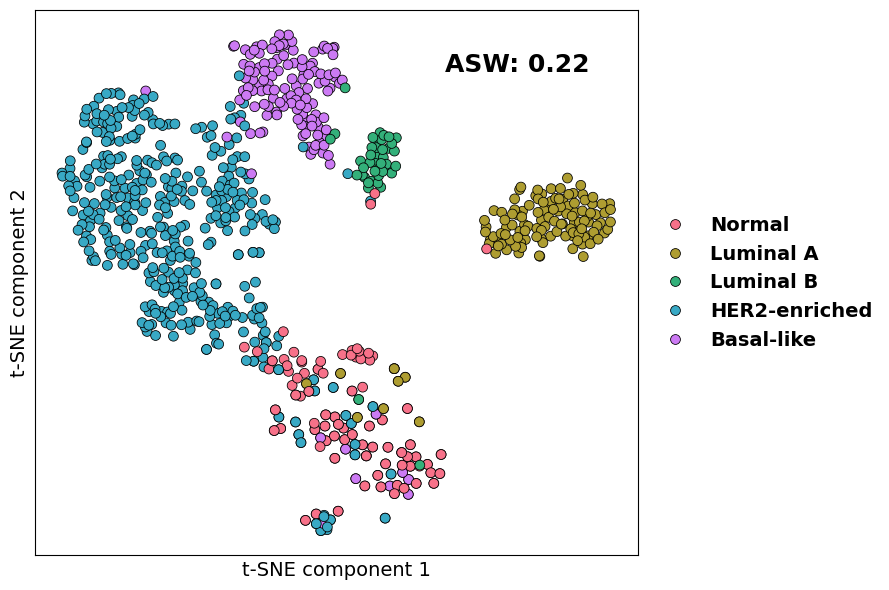

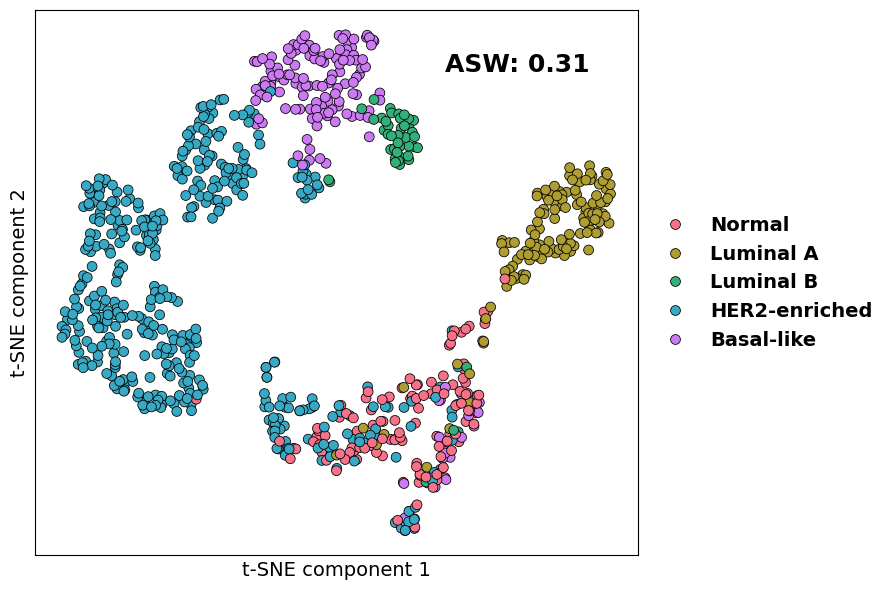

In [20]:
original_feature = MMfeature.cpu().numpy()
hypergraph_enhanced_feature = MMlogit.cpu().numpy()
print(original_feature.shape, hypergraph_enhanced_feature.shape)
print(len(label))

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

embed1 = original_feature
embed2 = hypergraph_enhanced_feature
asw1 = silhouette_score(embed1, label)
asw2 = silhouette_score(embed2, label)
print("ASW of embedding 1:", asw1)
print("ASW of embedding 2:", asw2)

# def evaluate_embedding_with_clustering(embedding, labels, n_clusters=5):
#     pred_labels = KMeans(n_clusters=n_clusters, random_state=0).fit_predict(embedding)
#     ari = adjusted_rand_score(labels, pred_labels)
#     nmi = normalized_mutual_info_score(labels, pred_labels)
#     silhouette = silhouette_score(embedding, pred_labels)
#     db_index = davies_bouldin_score(embedding, pred_labels)
#     return {'ARI': ari, 'NMI': nmi, 'Silhouette': silhouette, 'Davies-Bouldin': db_index}
# result1 = evaluate_embedding_with_clustering(embed1, label)
# result2 = evaluate_embedding_with_clustering(embed2, label)
# print("Embedding 1:", result1)
# print("Embedding 2:", result2)

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=2)
embed1 = tsne.fit_transform(original_feature)
embed2 = tsne.fit_transform(hypergraph_enhanced_feature)

# palette = 'viridis'
# palette = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324']
palette = sns.color_palette("husl", n_colors=5)  # Use a color palette with 5 distinct colors
label_dict = {0: 'Normal', 1: 'Luminal A', 2: 'Luminal B', 3: 'HER2-enriched', 4: 'Basal-like'}
label_to_color = dict(zip(label_dict.values(), palette))
label_name = [label_dict[i] for i in label]

# Plot the results for MMfeature
plt.figure(figsize=(9, 6))
scatter = sns.scatterplot(x=embed1[:, 0], y=embed1[:, 1], hue=label_name, palette=label_to_color, s=50, edgecolor='k')
# add the asw1 annotation of the upper right corner
# plt.text(0.8, 0.9, f'ASW: {asw1:.2f}', fontsize=18, fontstyle='italic', fontweight='bold', color='black', ha='center', va='center', transform=plt.gca().transAxes)
plt.text(0.8, 0.9, f'ASW: {asw1:.2f}', fontsize=18, fontweight='bold', color='black', ha='center', va='center', transform=plt.gca().transAxes)
plt.xticks([])
plt.yticks([])
# plt.xlabel('t-SNE component 1', fontsize=12, fontstyle='italic')
# plt.ylabel('t-SNE component 2', fontsize=12, fontstyle='italic')
plt.xlabel('t-SNE component 1', fontsize=14)
plt.ylabel('t-SNE component 2', fontsize=14)
handles, labels = scatter.get_legend_handles_labels()
sorted_labels = ['Normal', 'Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like']
sorted_handles = [handles[labels.index(label)] for label in sorted_labels]
# legend = plt.legend(handles=sorted_handles, labels=sorted_labels, loc='center left', title='', bbox_to_anchor=(1.0, 0.5), frameon=False, prop={'size': 12, 'style': 'italic', 'weight': 'bold'}, title_fontproperties={'size': 14, 'weight': 'bold', 'style': 'italic'})
legend = plt.legend(handles=sorted_handles, labels=sorted_labels, loc='center left', title='', bbox_to_anchor=(1.0, 0.5), frameon=False, prop={'size': 14, 'weight': 'bold'}, title_fontproperties={'size': 14, 'weight': 'bold'})
plt.tight_layout()
plt.savefig(f'./figure/data_MOGONET/inter_3.png', dpi=400, bbox_inches='tight')
plt.show()

# Plot the results for MMfeature_hypergraph
plt.figure(figsize=(9, 6))
scatter = sns.scatterplot(x=embed2[:, 0], y=embed2[:, 1], hue=label_name, palette=label_to_color, s=50, edgecolor='k')
# plt.text(0.8, 0.9, f'ASW: {asw2:.2f}', fontsize=18, fontstyle='italic', fontweight='bold', color='black', ha='center', va='center', transform=plt.gca().transAxes)
plt.text(0.8, 0.9, f'ASW: {asw2:.2f}', fontsize=18, fontweight='bold', color='black', ha='center', va='center', transform=plt.gca().transAxes)
plt.xticks([])
plt.yticks([])
# plt.xlabel('t-SNE component 1', fontsize=12, fontstyle='italic')
# plt.ylabel('t-SNE component 2', fontsize=12, fontstyle='italic')
plt.xlabel('t-SNE component 1', fontsize=14)
plt.ylabel('t-SNE component 2', fontsize=14)
handles, labels = scatter.get_legend_handles_labels()
sorted_labels = ['Normal', 'Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like']
sorted_handles = [handles[labels.index(label)] for label in sorted_labels]
# legend = plt.legend(handles=sorted_handles, labels=sorted_labels, loc='center left', title='', bbox_to_anchor=(1.0, 0.5), frameon=False, prop={'size': 12, 'style': 'italic', 'weight': 'bold'}, title_fontproperties={'size': 14, 'weight': 'bold', 'style': 'italic'})
legend = plt.legend(handles=sorted_handles, labels=sorted_labels, loc='center left', title='', bbox_to_anchor=(1.0, 0.5), frameon=False, prop={'size': 14, 'weight': 'bold'}, title_fontproperties={'size': 14, 'weight': 'bold'})
# delete the spines
# plt.gca().spines['top'].set_visible(False)
# plt.gca().spines['right'].set_visible(False)
# plt.gca().spines['left'].set_visible(False)
# plt.gca().spines['bottom'].set_visible(False)
plt.tight_layout()
plt.savefig(f'./figure/data_MOGONET/inter_5.png', dpi=400, bbox_inches='tight')
plt.show()

Index(['Normal', 'Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like'], dtype='object', name='label')


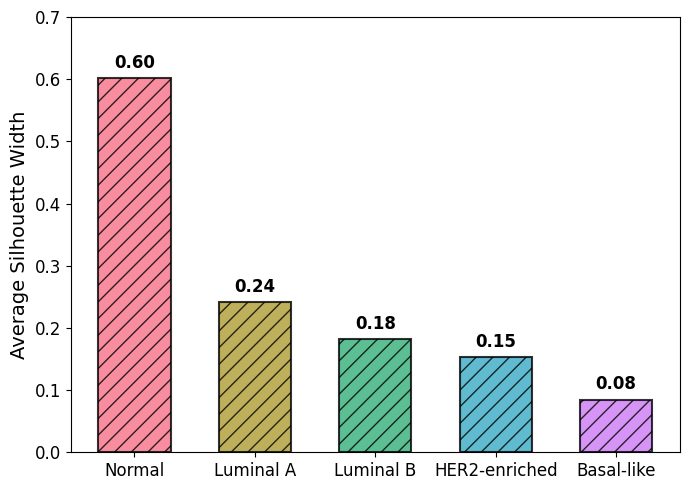

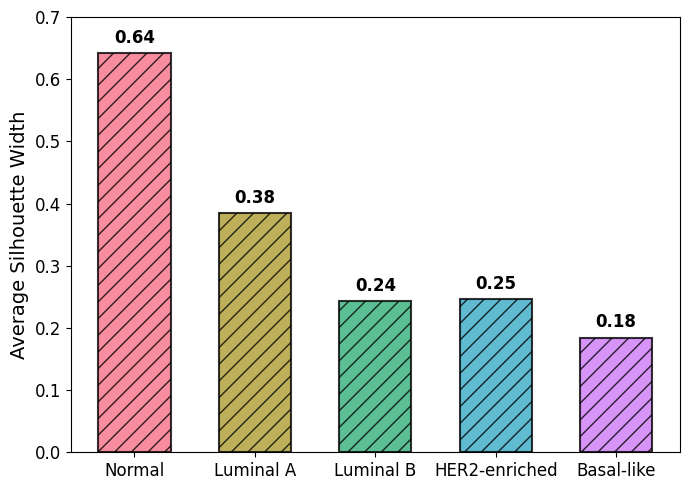

In [23]:
from sklearn.metrics import silhouette_samples

def compute_per_class_asw(embedding, labels):
    sample_silhouettes = silhouette_samples(embedding, labels)
    df = pd.DataFrame({'label': labels, 'silhouette': sample_silhouettes})
    per_class_asw = df.groupby('label')['silhouette'].mean() # .sort_values(ascending=False)
    return per_class_asw

palette = sns.color_palette("husl", n_colors=5)  # Use a color palette with 5 distinct colors
asw_per_class = compute_per_class_asw(original_feature, label_name)
asw_per_class = asw_per_class[['Normal', 'Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like']]
print(asw_per_class.index)
colors = dict(zip(asw_per_class.index, palette))

plt.figure(figsize=(7, 5))
bars = plt.bar(asw_per_class.index, asw_per_class.values, color=[colors[label] for label in asw_per_class.index], alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6, hatch='//')
for bar in bars:
    height = bar.get_height()
    # plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontstyle='italic', fontweight='bold')
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
# plt.xticks(fontsize=12, fontstyle='italic', fontweight='normal')
# plt.yticks(fontsize=12, fontstyle='italic', fontweight='normal')
plt.xticks(fontsize=12, fontweight='normal')
plt.yticks(fontsize=12, fontweight='normal')
plt.ylim(0, 0.7)
# plt.xlabel('Class Label', fontsize=14, fontstyle='italic', fontweight='bold')
# plt.ylabel('Average Silhouette Width', fontsize=14, fontstyle='italic', fontweight='normal')
plt.ylabel('Average Silhouette Width', fontsize=14, fontweight='normal')
# plt.title('Per-Class ASW in Embedding Space', fontsize=16, fontstyle='italic', fontweight='bold')
plt.tight_layout()
plt.savefig(f'./figure/data_MOGONET/inter_4.png', dpi=400, bbox_inches='tight')
plt.show()

asw_per_class = compute_per_class_asw(hypergraph_enhanced_feature, label_name)
asw_per_class = asw_per_class[['Normal', 'Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like']]
plt.figure(figsize=(7, 5))
bars = plt.bar(asw_per_class.index, asw_per_class.values, color=[colors[label] for label in asw_per_class.index], alpha=0.8, edgecolor='black', linewidth=1.5, width=0.6, hatch='//')
for bar in bars:
    height = bar.get_height()
    # plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontstyle='italic', fontweight='bold')
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
# plt.xticks(fontsize=12, fontstyle='italic', fontweight='normal')
# plt.yticks(fontsize=12, fontstyle='italic', fontweight='normal')
plt.xticks(fontsize=12, fontweight='normal')
plt.yticks(fontsize=12, fontweight='normal')
plt.ylim(0, 0.7)
# plt.xlabel('Class Label', fontsize=14, fontstyle='italic', fontweight='bold')
# plt.ylabel('Average Silhouette Width', fontsize=14, fontstyle='italic', fontweight='normal')
plt.ylabel('Average Silhouette Width', fontsize=14, fontweight='normal')
# plt.title('Per-Class ASW in Embedding Space', fontsize=16, fontstyle='italic', fontweight='bold')
plt.tight_layout()
# delete the axis spines
# plt.gca().spines['top'].set_visible(False)
# plt.gca().spines['right'].set_visible(False)
# plt.gca().spines['left'].set_visible(False)
# plt.gca().spines['bottom'].set_visible(False)
# add vertical grid lines
# plt.gca().yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray')
plt.savefig(f'./figure/data_MOGONET/inter_6.png', dpi=400, bbox_inches='tight')
plt.show()